analysing the data

DETAILS OF THE DATASET

Input features in order:
1) CRIM: per capita crime rate by town
2) ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3) INDUS: proportion of non-retail business acres per town
4) CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5) NOX: nitric oxides concentration (parts per 10 million) [parts/10M]
6) RM: average number of rooms per dwelling
7) AGE: proportion of owner-occupied units built prior to 1940
8) DIS: weighted distances to five Boston employment centres
9) RAD: index of accessibility to radial highways
10) TAX: full-value property-tax rate per $10,000 [$/10k]
11) PTRATIO: pupil-teacher ratio by town
12) B: The result of the equation B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13) LSTAT: % lower status of the population

Output variable:
1) MEDV: Median value of owner-occupied homes in $1000's [k$]

MORE SIMPLE DATASET OVERVIEW

Here’s each Boston housing column in **plain language**.

- **CRIM** – crime rate in the area. Higher value = more crimes per person in that town.
- **ZN** – percentage of land with big residential plots (large houses on big lots). 
- **INDUS** – percentage of land used for factories/industry (non‑retail business). 
- **CHAS** – is the area next to the Charles River? 1 = yes, 0 = no. 
- **NOX** – air pollution level (nitric oxide concentration). 
- **RM** – average number of rooms per house in the area. 
- **AGE** – percentage of houses that are old (built long ago, owner‑occupied). 
- **DIS** – average distance to major job centers (how far people must travel to work).
- **RAD** – rating of how easy it is to reach main highways (higher = better access).
- **TAX** – property tax rate in that area (per 10,000 dollars of value). 
- **PTRATIO** – number of students per teacher in local schools (pupil–teacher ratio). 
- **B** – a race‑related index based on proportion of Black residents (this variable is now considered problematic and biased, which is one reason the dataset is discouraged in new work). 
- **LSTAT** – percentage of people in the area with lower income or social status. 
- **MEDV** – target column: median value of houses in the area (in thousands of dollars). 

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("RandomForest\RFR\RFR_01\Boston_house.csv")

In [2]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
dfu = df.copy()

Visual EDA

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

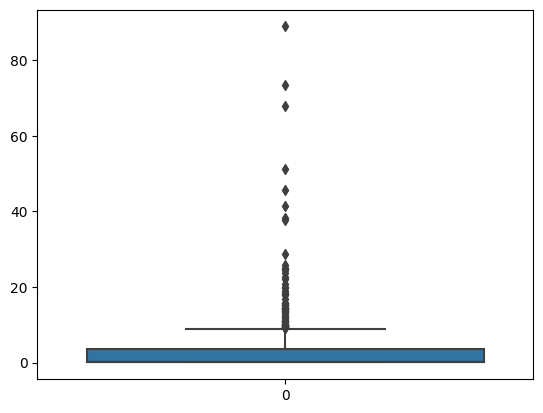

In [7]:
sns.boxplot(dfu['CRIM'])
plt.show()

log transforming 'CRIM'

In [8]:
dfu['CRIM_log1'] = np.log1p(dfu['CRIM'])

<AxesSubplot:>

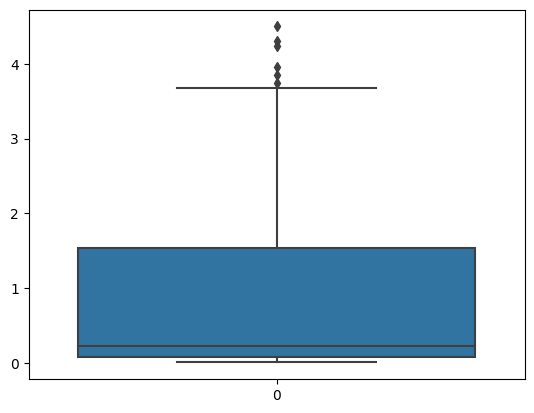

In [9]:
sns.boxplot(dfu['CRIM_log1'])

Trying with the IQR CAPPING 'CRIM'

In [10]:
# Q1 = dfu['CRIM'].quantile(0.25)
# Q3 = dfu['CRIM'].quantile(0.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5*IQR
# upper = Q1 + 1.5*IQR
# dfu['CRIM_cap'] = dfu['CRIM'].clip(lower, upper)

In [11]:
# sns.boxplot(dfu['CRIM_cap'])

In [12]:
# dfu.info()

In [13]:
# dfu.isna().sum()

In [14]:
# df.isnull().sum()

Univariate analysis of ZN

<AxesSubplot:>

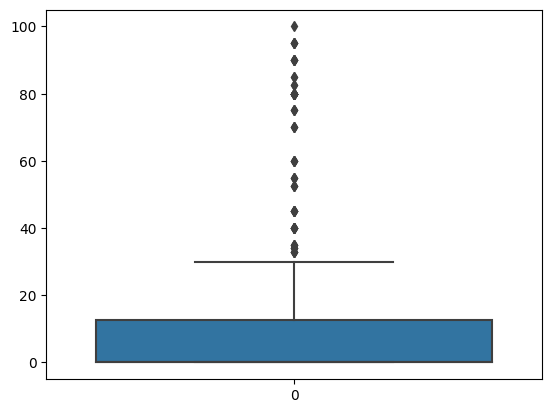

In [15]:
sns.boxplot(dfu['ZN'])

<AxesSubplot:>

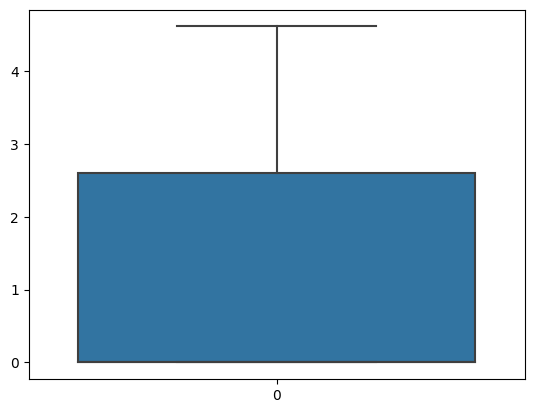

In [16]:
dfu['ZN_log'] = np.log1p(dfu['ZN'])
sns.boxplot(dfu['ZN_log'])

In [17]:
dfu.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,CRIM_log1,ZN_log
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,0.006300,2.944439
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,0.026944,0.000000
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,0.026924,0.000000
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,0.031857,0.000000
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,0.066770,0.000000


UNIVARIATE ANALYSIS OF INDUS

<AxesSubplot:>

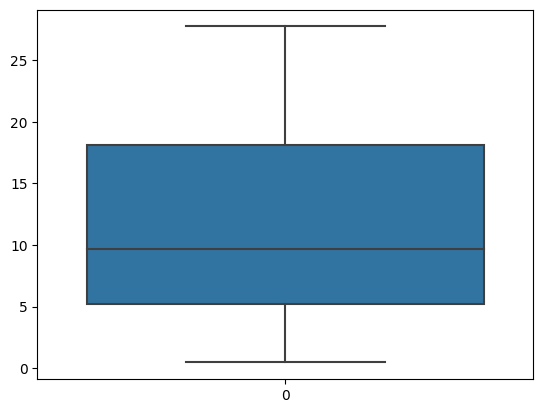

In [18]:
sns.boxplot(dfu['INDUS'])

UNIVARIATE ANALYSIS OF NOX

<AxesSubplot:>

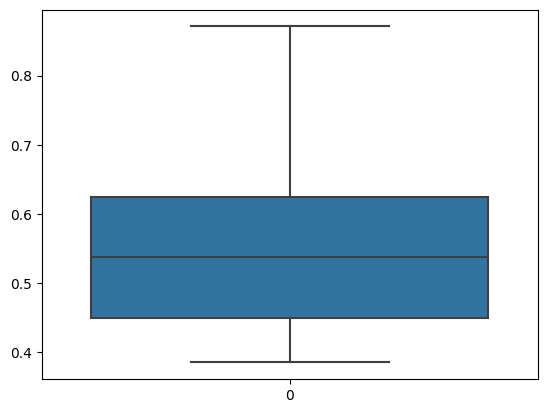

In [19]:
sns.boxplot(dfu['NOX'])

UNIVARIATE ANALYSIS OF RM

<AxesSubplot:>

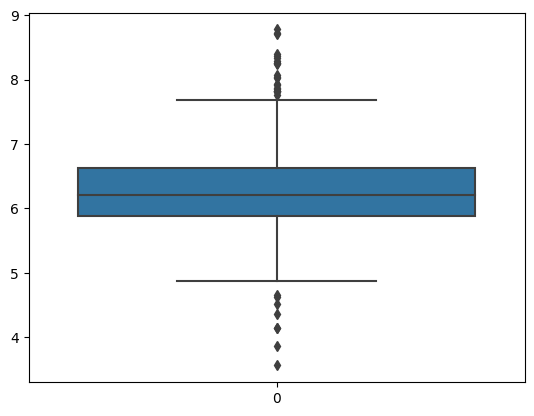

In [20]:
sns.boxplot(dfu['RM'])

IQR capping the RM

<AxesSubplot:>

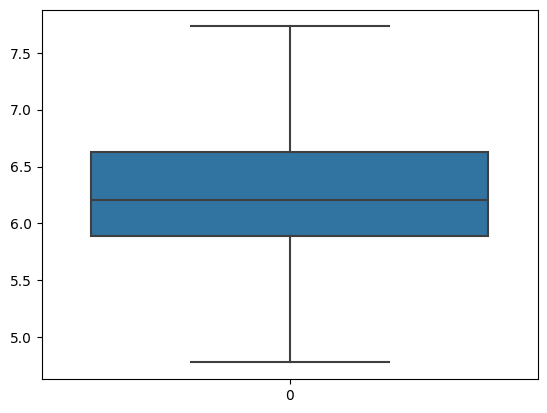

In [21]:
Q1 = dfu['RM'].quantile(0.25)
Q3 = dfu['RM'].quantile(0.75)


IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

dfu['RM_cap'] = dfu['RM'].clip(lower, upper)


sns.boxplot(dfu['RM_cap'])

In [22]:
dfu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM       506 non-null    float64
 1   ZN         506 non-null    float64
 2   INDUS      506 non-null    float64
 3   CHAS       506 non-null    int64  
 4   NOX        506 non-null    float64
 5   RM         506 non-null    float64
 6   AGE        506 non-null    float64
 7   DIS        506 non-null    float64
 8   RAD        506 non-null    int64  
 9   TAX        506 non-null    float64
 10  PTRATIO    506 non-null    float64
 11  B          506 non-null    float64
 12  LSTAT      506 non-null    float64
 13  MEDV       506 non-null    float64
 14  CRIM_log1  506 non-null    float64
 15  ZN_log     506 non-null    float64
 16  RM_cap     506 non-null    float64
dtypes: float64(15), int64(2)
memory usage: 67.3 KB


<AxesSubplot:>

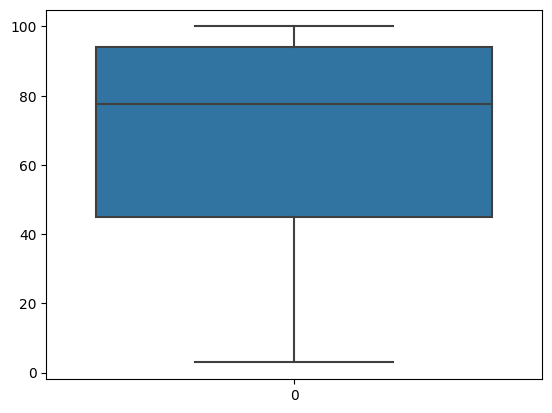

In [23]:
sns.boxplot(dfu['AGE'])

In [24]:
dfu['DIS']

0      4.0900
1      4.9671
2      4.9671
3      6.0622
4      6.0622
        ...  
501    2.4786
502    2.2875
503    2.1675
504    2.3889
505    2.5050
Name: DIS, Length: 506, dtype: float64

<AxesSubplot:>

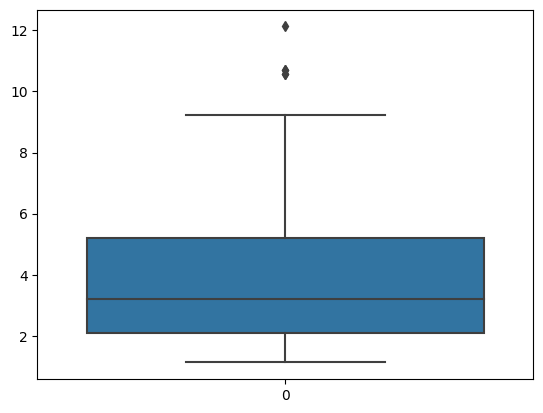

In [25]:
sns.boxplot(dfu['DIS'])

<AxesSubplot:>

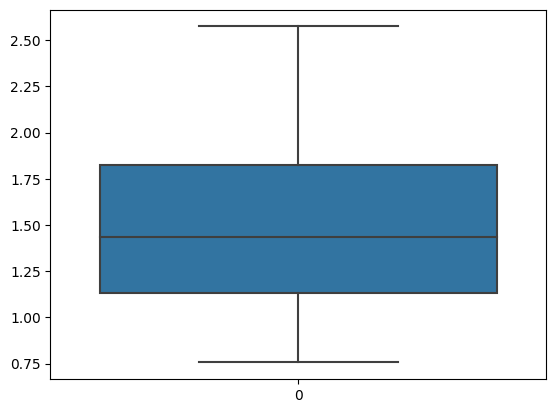

In [26]:
dfu['DIS_log'] = np.log1p(dfu['DIS'])
sns.boxplot(dfu['DIS_log'])

In [27]:
dfu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM       506 non-null    float64
 1   ZN         506 non-null    float64
 2   INDUS      506 non-null    float64
 3   CHAS       506 non-null    int64  
 4   NOX        506 non-null    float64
 5   RM         506 non-null    float64
 6   AGE        506 non-null    float64
 7   DIS        506 non-null    float64
 8   RAD        506 non-null    int64  
 9   TAX        506 non-null    float64
 10  PTRATIO    506 non-null    float64
 11  B          506 non-null    float64
 12  LSTAT      506 non-null    float64
 13  MEDV       506 non-null    float64
 14  CRIM_log1  506 non-null    float64
 15  ZN_log     506 non-null    float64
 16  RM_cap     506 non-null    float64
 17  DIS_log    506 non-null    float64
dtypes: float64(16), int64(2)
memory usage: 71.3 KB


In [28]:
dfu['RAD'].value_counts() #SHOULD BE KEPT to standard scale later

24    132
5     115
4     110
3      38
6      26
2      24
8      24
1      20
7      17
Name: RAD, dtype: int64

<AxesSubplot:>

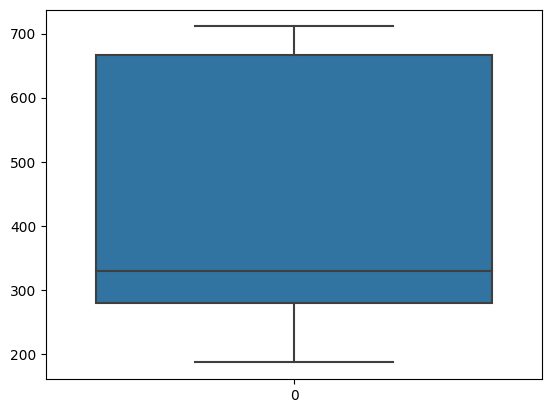

In [29]:
sns.boxplot(dfu['TAX'])

<AxesSubplot:>

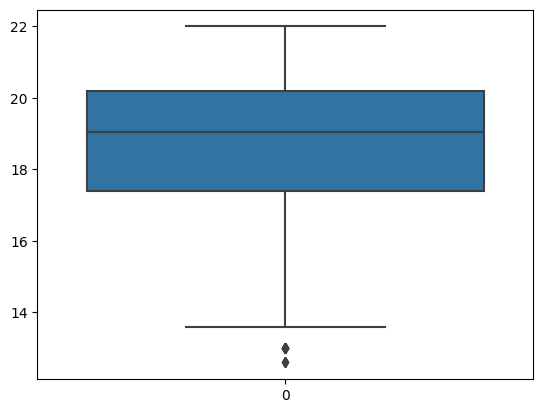

In [30]:
sns.boxplot(dfu['PTRATIO']) #WILL BE STANDARD SCALED

<AxesSubplot:>

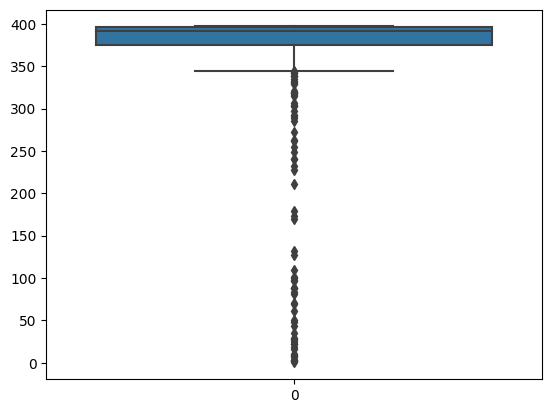

In [31]:
sns.boxplot(dfu['B']) #JUST FOR LEARNING THE BIASNESS

<AxesSubplot:>

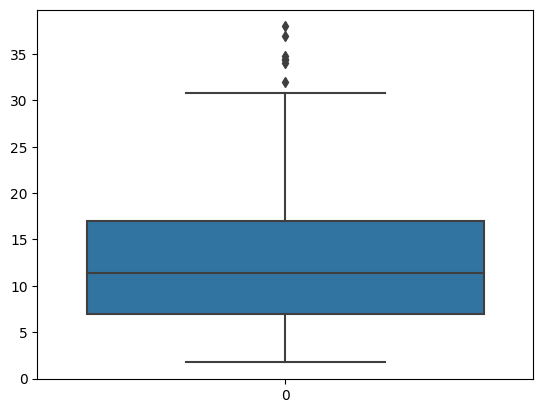

In [32]:
sns.boxplot(dfu['LSTAT'])

In [33]:
dfu['LSTAT'].value_counts()

7.79     3
14.10    3
6.36     3
18.13    3
8.05     3
        ..
3.32     1
1.92     1
1.73     1
6.43     1
7.88     1
Name: LSTAT, Length: 455, dtype: int64

In [34]:
dfu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM       506 non-null    float64
 1   ZN         506 non-null    float64
 2   INDUS      506 non-null    float64
 3   CHAS       506 non-null    int64  
 4   NOX        506 non-null    float64
 5   RM         506 non-null    float64
 6   AGE        506 non-null    float64
 7   DIS        506 non-null    float64
 8   RAD        506 non-null    int64  
 9   TAX        506 non-null    float64
 10  PTRATIO    506 non-null    float64
 11  B          506 non-null    float64
 12  LSTAT      506 non-null    float64
 13  MEDV       506 non-null    float64
 14  CRIM_log1  506 non-null    float64
 15  ZN_log     506 non-null    float64
 16  RM_cap     506 non-null    float64
 17  DIS_log    506 non-null    float64
dtypes: float64(16), int64(2)
memory usage: 71.3 KB


<AxesSubplot:>

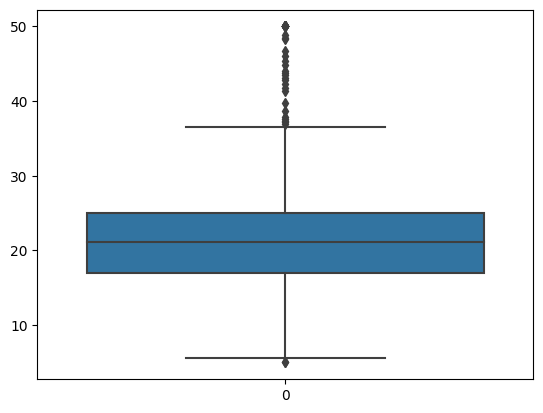

In [35]:
sns.boxplot(dfu['MEDV'])

In [36]:
dfu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM       506 non-null    float64
 1   ZN         506 non-null    float64
 2   INDUS      506 non-null    float64
 3   CHAS       506 non-null    int64  
 4   NOX        506 non-null    float64
 5   RM         506 non-null    float64
 6   AGE        506 non-null    float64
 7   DIS        506 non-null    float64
 8   RAD        506 non-null    int64  
 9   TAX        506 non-null    float64
 10  PTRATIO    506 non-null    float64
 11  B          506 non-null    float64
 12  LSTAT      506 non-null    float64
 13  MEDV       506 non-null    float64
 14  CRIM_log1  506 non-null    float64
 15  ZN_log     506 non-null    float64
 16  RM_cap     506 non-null    float64
 17  DIS_log    506 non-null    float64
dtypes: float64(16), int64(2)
memory usage: 71.3 KB


In [37]:
dfu.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,CRIM_log1,ZN_log,RM_cap,DIS_log
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,0.006300,2.944439,6.575,1.627278
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,0.026944,0.000000,6.421,1.786261
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,0.026924,0.000000,7.185,1.786261
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,0.031857,0.000000,6.998,1.954757
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,0.066770,0.000000,7.147,1.954757


In [38]:
num_col = ['CRIM_log1', 'ZN_log', 'INDUS', 'NOX', 'RM_cap', 'AGE', 'DIS_log', 'TAX', 'PTRATIO', 'LSTAT']
no_change_col = ['RAD', 'CHAS']
target = ['MEDV']

bivariate analysis with the target

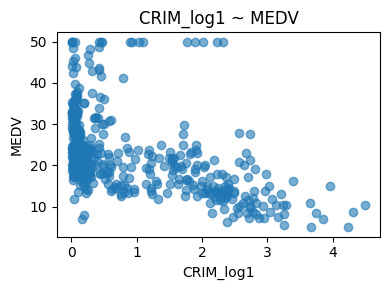

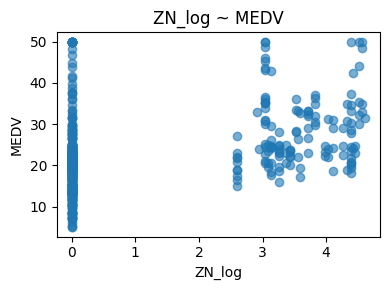

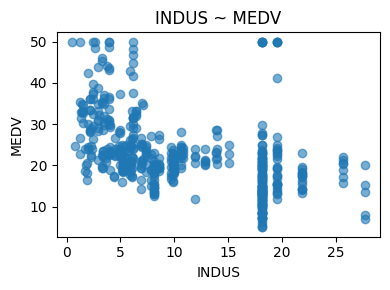

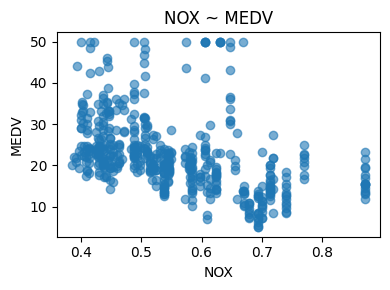

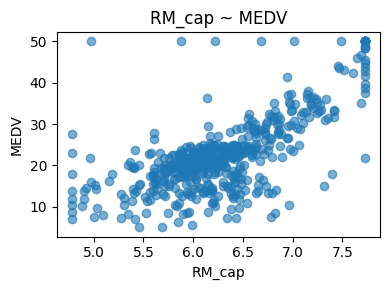

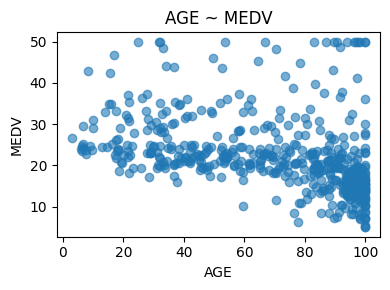

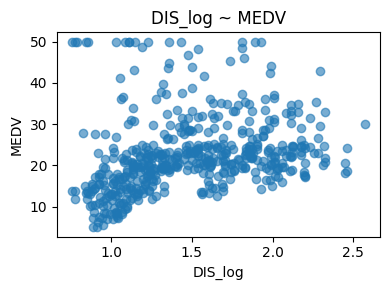

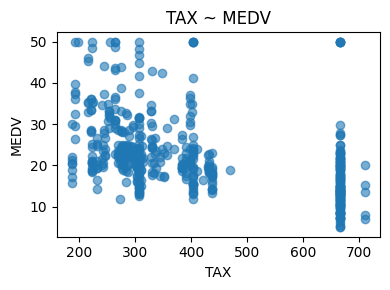

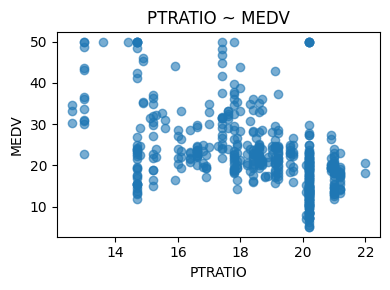

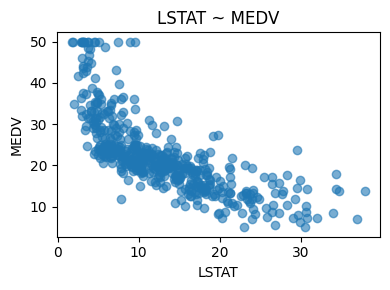

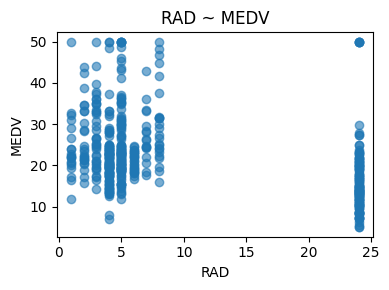

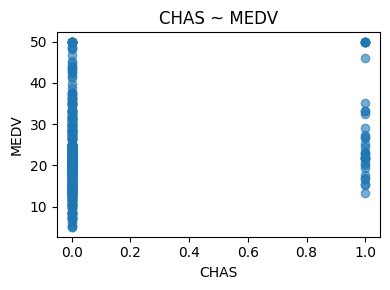

In [39]:
df_tempx = dfu[num_col + no_change_col]
df_tempy = dfu[target]

for col in df_tempx.columns:
    plt.figure(figsize = (4,3))
    plt.scatter(df_tempx[col], df_tempy, alpha = 0.6)
    plt.xlabel(col)
    plt.ylabel('MEDV')
    plt.title(f"{col} ~ MEDV")
    plt.tight_layout()
    plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM_log1  506 non-null    float64
 1   ZN_log     506 non-null    float64
 2   INDUS      506 non-null    float64
 3   NOX        506 non-null    float64
 4   RM_cap     506 non-null    float64
 5   AGE        506 non-null    float64
 6   DIS_log    506 non-null    float64
 7   TAX        506 non-null    float64
 8   PTRATIO    506 non-null    float64
 9   LSTAT      506 non-null    float64
 10  RAD        506 non-null    int64  
 11  CHAS       506 non-null    int64  
 12  MEDV       506 non-null    float64
dtypes: float64(11), int64(2)
memory usage: 51.5 KB


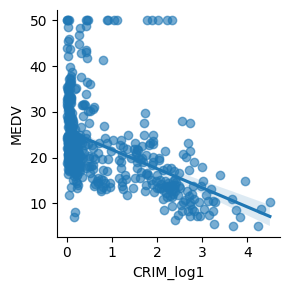

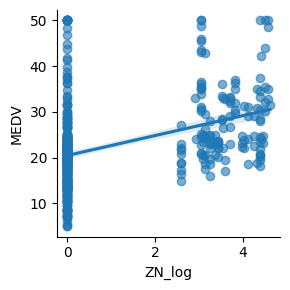

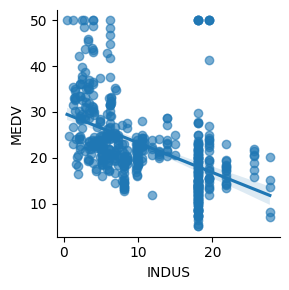

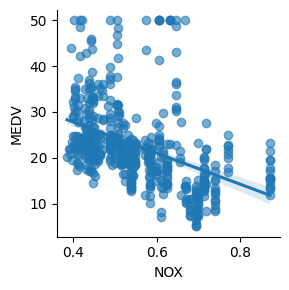

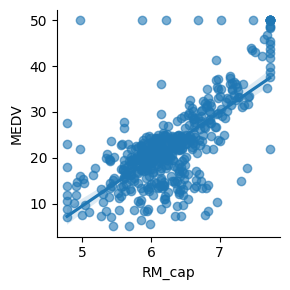

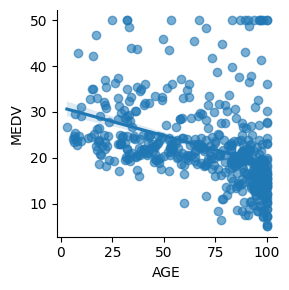

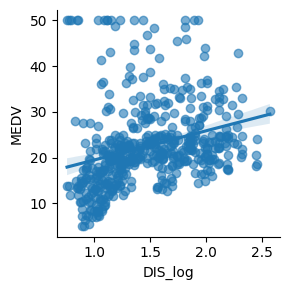

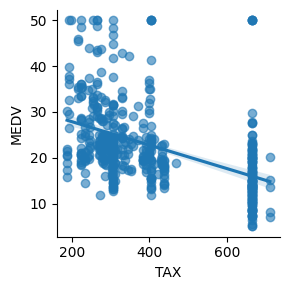

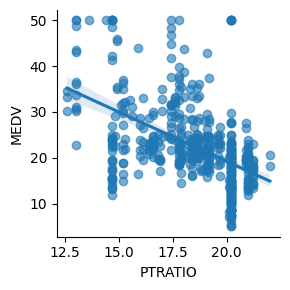

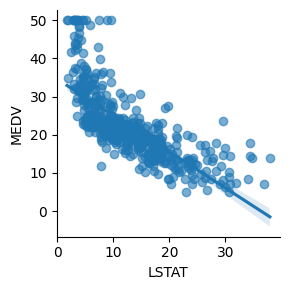

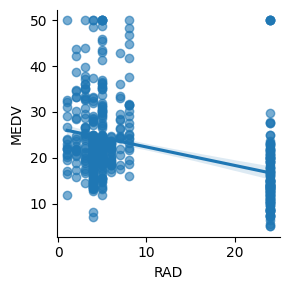

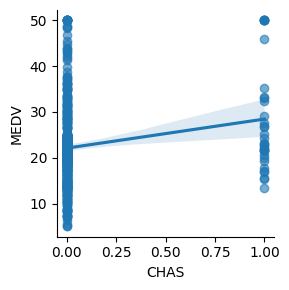

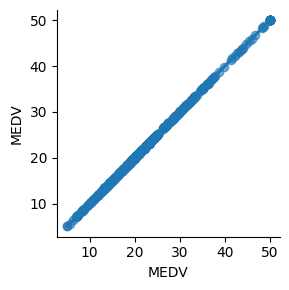

In [40]:
temp = dfu[num_col + no_change_col + target]
temp.info()

for col in temp.columns:
    sns.lmplot(data=temp, x=col, y="MEDV", height=3, scatter_kws={"alpha":0.6})

num_col = ['CRIM_log1', 'ZN_log', 'INDUS', 'NOX', 'RM_cap', 'AGE', 'DIS_log', 'TAX', 'PTRATIO', 'LSTAT']

no_change_col = ['RAD', 'CHAS']

target = ['MEDV']

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

preprocess = ColumnTransformer(transformers = [('num', StandardScaler(), num_col), ('no_change', 'passthrough', no_change_col)])
RFR = RandomForestRegressor(n_estimators = 100, random_state = 42, max_depth = None, n_jobs = -1, min_samples_leaf = 1)
model = Pipeline(steps = [('preprocessing', preprocess), ('RFR', RFR)])

In [42]:
dfu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM       506 non-null    float64
 1   ZN         506 non-null    float64
 2   INDUS      506 non-null    float64
 3   CHAS       506 non-null    int64  
 4   NOX        506 non-null    float64
 5   RM         506 non-null    float64
 6   AGE        506 non-null    float64
 7   DIS        506 non-null    float64
 8   RAD        506 non-null    int64  
 9   TAX        506 non-null    float64
 10  PTRATIO    506 non-null    float64
 11  B          506 non-null    float64
 12  LSTAT      506 non-null    float64
 13  MEDV       506 non-null    float64
 14  CRIM_log1  506 non-null    float64
 15  ZN_log     506 non-null    float64
 16  RM_cap     506 non-null    float64
 17  DIS_log    506 non-null    float64
dtypes: float64(16), int64(2)
memory usage: 71.3 KB


In [43]:
X = dfu[num_col + no_change_col]
y = dfu[target]

In [44]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM_log1  506 non-null    float64
 1   ZN_log     506 non-null    float64
 2   INDUS      506 non-null    float64
 3   NOX        506 non-null    float64
 4   RM_cap     506 non-null    float64
 5   AGE        506 non-null    float64
 6   DIS_log    506 non-null    float64
 7   TAX        506 non-null    float64
 8   PTRATIO    506 non-null    float64
 9   LSTAT      506 non-null    float64
 10  RAD        506 non-null    int64  
 11  CHAS       506 non-null    int64  
dtypes: float64(10), int64(2)
memory usage: 47.6 KB


In [45]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MEDV    506 non-null    float64
dtypes: float64(1)
memory usage: 4.1 KB


In [46]:
from sklearn.model_selection import train_test_split

[X_train,X_test, y_train, y_test] = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [47]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

c:\users\lenovo\.pyenv\pyenv-win\versions\3.7.4\lib\site-packages\sklearn\pipeline.py:394: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)


In [48]:
y_pred.shape

(102,)

In [49]:
y_test.shape

(102, 1)

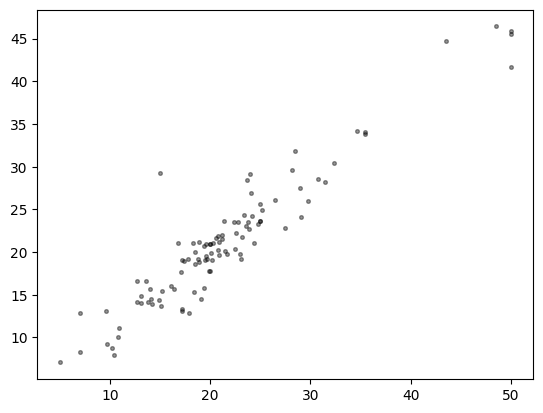

In [50]:
plt.scatter(y_test,y_pred, s = 7, color = 'black', alpha = 0.4)

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mse)

print(f"Mean absolute error : {mae}\nMean squared error  : {mse}\nR2_score : {r2}\nRoot mean squared error : {rmse}")

Mean absolute error : 1.9722156862745104
Mean squared error  : 7.839977392156865
R2_score : 0.8930918731546
Root mean squared error : 2.799995962882244
